In [17]:
!pip install TA-Lib mplfinance quantstats seaborn scikit-learn yfinance

# Quantitative Trading Architecture: Vanilla Baseline Diagnostics

Targets **Reversal Zone** detection using a simple, sequential GRU.
Target labels are generated using a Centered Moving Average Extrema Scanner.
The network is trained directly on hard labels (0, 1, 2) using standard Cross-Entropy Loss on the final sequence step.

In [18]:
import math
import copy
import warnings
import itertools
import numpy as np
import pandas as pd
import yfinance as yf
import talib
from scipy.signal import find_peaks

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
import quantstats as qs

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {DEVICE}")

Using compute device: cuda


## Phase I: Data Pipeline & Labeling

In [24]:
class MarketDataPipeline:
    def __init__(self, ticker, start_date, end_date, time_steps=10):
        self.ticker = ticker
        self.start_date = pd.to_datetime(start_date) - pd.Timedelta(days=400)
        self.end_date = end_date
        self.time_steps = time_steps

        self.micro_cols = ['Micro_RSI', 'Micro_RSI_Slope', 'Micro_FastK', 'Micro_FastD', 'Micro_Prc_Dev', 'Micro_Vol_Burst', 'Micro_Ret_Accel']
        self.macro_cols = ['Macro_RSI', 'Macro_FastK', 'Macro_FastD', 'Macro_Prc_Dev', 'Macro_Vol_Base', 'Macro_Ret_Vel']
        self.feature_columns = self.micro_cols + self.macro_cols

    def fetch_data(self):
        df = yf.download(self.ticker, start=self.start_date, end=self.end_date, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df.dropna()

    def compute_features(self, df):
        df['Micro_RSI'] = talib.RSI(df['Close'], timeperiod=14) / 100.0
        df['Micro_RSI_Slope'] = df['Micro_RSI'].diff(3)
        fastk, fastd = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=5, fastd_period=3, fastd_matype=0)
        df['Micro_FastK'] = fastk / 100.0
        df['Micro_FastD'] = fastd / 100.0
        sma_20 = talib.SMA(df['Close'], timeperiod=20)
        df['Micro_Prc_Dev'] = (df['Close'] / sma_20) - 1.0
        sma_vol_20 = talib.SMA(df['Volume'], timeperiod=20).replace(0, np.nan)
        df['Micro_Vol_Burst'] = (df['Volume'] / sma_vol_20).fillna(1.0)
        df['Micro_Ret_Accel'] = df['Close'].pct_change() - df['Close'].pct_change().rolling(window=5).mean()

        df['Macro_RSI'] = talib.RSI(df['Close'], timeperiod=50) / 100.0
        fastk_m, fastd_m = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=20, fastd_period=5, fastd_matype=0)
        df['Macro_FastK'] = fastk_m / 100.0
        df['Macro_FastD'] = fastd_m / 100.0
        sma_200 = talib.SMA(df['Close'], timeperiod=200)
        df['Macro_Prc_Dev'] = (df['Close'] / sma_200) - 1.0
        sma_vol_100 = talib.SMA(df['Volume'], timeperiod=100).replace(0, np.nan)
        df['Macro_Vol_Base'] = (sma_vol_20 / sma_vol_100).fillna(1.0)
        df['Macro_Ret_Vel'] = df['Close'] / df['Close'].shift(10) - 1.0

        df['5D_MA'] = talib.SMA(df['Close'], timeperiod=5)
        df['20D_MA'] = sma_20
        return df.fillna(0)

    def assign_dynamic_labels(self, prices, extrema_indices, extrema_types, max_pad=1):
        labels = np.full(len(prices), 2)
        n_extrema = len(extrema_indices)
        for i in range(n_extrema):
            curr_idx = extrema_indices[i]
            curr_type = extrema_types[i]
            dist_prev = (curr_idx - extrema_indices[i-1]) if i > 0 else max_pad * 2 + 1
            dist_next = (extrema_indices[i+1] - curr_idx) if i < n_extrema - 1 else max_pad * 2 + 1
            pad_left = min(max_pad, max(0, (dist_prev - 1) // 2))
            pad_right = min(max_pad, max(0, (dist_next - 1) // 2))
            labels[curr_idx - pad_left : curr_idx + pad_right + 1] = curr_type
        return labels

    def generate_labels(self, df):
        prices = df['Close'].values
        centered_sma = pd.Series(prices).rolling(window=7, center=True).mean().values
        valid_idx = ~np.isnan(centered_sma)

        # 3.5% swing threshold to ensure macro-level extrema
        min_swing = np.nanmean(centered_sma) * 0.03
        coarse_peaks, _ = find_peaks(centered_sma[valid_idx], distance=7, prominence=min_swing)
        coarse_troughs, _ = find_peaks(-centered_sma[valid_idx], distance=7, prominence=min_swing)

        offset = np.argmax(valid_idx)
        coarse_peaks += offset
        coarse_troughs += offset

        fine_extrema = []
        for cp in coarse_peaks:
            start = max(0, cp - 1)
            end = min(len(prices), cp + 2)
            fine_extrema.append((start + np.argmax(prices[start:end]), 1))

        for ct in coarse_troughs:
            start = max(0, ct - 1)
            end = min(len(prices), ct + 2)
            fine_extrema.append((start + np.argmin(prices[start:end]), 0))

        fine_extrema = sorted(list(set(fine_extrema)), key=lambda x: x[0])

        if len(fine_extrema) > 0:
            ext_indices, ext_types = zip(*fine_extrema)
            labels = self.assign_dynamic_labels(prices, ext_indices, ext_types, max_pad=1)
        else:
            labels = np.full(len(prices), 2)

        df['Regime'] = labels
        return df.dropna()

    def prepare_data(self, val_days, test_days):
        raw_df = self.fetch_data()
        df = self.compute_features(raw_df)
        self.clean_df = self.generate_labels(df)

        features = self.clean_df[self.feature_columns].values
        labels = self.clean_df['Regime'].values

        X, Y = [], []
        for i in range(len(features) - self.time_steps + 1):
            X.append(features[i:(i + self.time_steps)])
            Y.append(labels[i + self.time_steps - 1])

        X, Y = np.array(X), np.array(Y, dtype=np.int64)
        self.clean_df = self.clean_df.iloc[-len(X):].copy()

        test_idx = len(X) - test_days
        val_idx = test_idx - val_days

        X_train, X_val, X_test = X[:val_idx], X[val_idx:test_idx], X[test_idx:]
        Y_train, Y_val, Y_test = Y[:val_idx], Y[val_idx:test_idx], Y[test_idx:]

        self.scaler = StandardScaler()
        B, T, F = X_train.shape
        X_train_reshaped = X_train.reshape(-1, F)
        self.scaler.fit(X_train_reshaped)

        X_train = self.scaler.transform(X_train_reshaped).reshape(B, T, F)
        X_val = self.scaler.transform(X_val.reshape(-1, F)).reshape(X_val.shape[0], T, F)
        X_test = self.scaler.transform(X_test.reshape(-1, F)).reshape(X_test.shape[0], T, F)

        return X_train, X_val, X_test, Y_train, Y_val, Y_test, self.clean_df

## Phase Ib: Ground Truth Label Verification Plot

Preparing Centered Data Pipeline (Train / Val / Test)...

--- LABEL VERIFICATION: Review Ground Truth Mapping ---


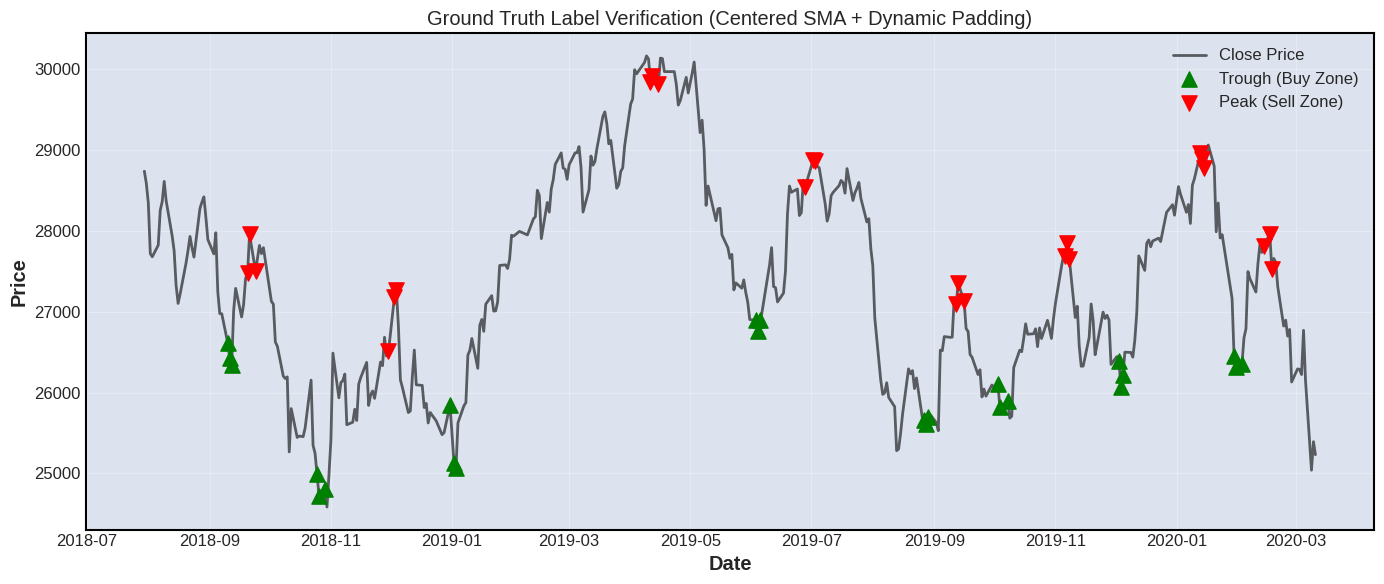

In [25]:
def plot_label_verification(df, start_idx=-400, end_idx=-100):
    print("\n--- LABEL VERIFICATION: Review Ground Truth Mapping ---")
    plot_df = df.iloc[start_idx:end_idx].copy()

    plt.figure(figsize=(14, 6))
    plt.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black', alpha=0.6)

    troughs = plot_df[plot_df['Regime'] == 0]
    plt.scatter(troughs.index, troughs['Close'], color='green', marker='^', s=120, label='Trough (Buy Zone)', zorder=5)

    peaks = plot_df[plot_df['Regime'] == 1]
    plt.scatter(peaks.index, peaks['Close'], color='red', marker='v', s=120, label='Peak (Sell Zone)', zorder=5)

    plt.title('Ground Truth Label Verification (Centered SMA + Dynamic Padding)')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- EXECUTION: DATA PIPELINE & LABEL VERIFICATION ---
TICKER = "^HSI"
START_DATE = "2011-01-01"
END_DATE = "2021-01-01"
VAL_DAYS_N = 504
TEST_DAYS_N = 504

print("Preparing Centered Data Pipeline (Train / Val / Test)...")
pipeline = MarketDataPipeline(ticker=TICKER, start_date=START_DATE, end_date=END_DATE, time_steps=10)
X_train, X_val, X_test, Y_train, Y_val, Y_test, clean_df = pipeline.prepare_data(val_days=VAL_DAYS_N, test_days=TEST_DAYS_N)

plot_label_verification(clean_df, start_idx=-600, end_idx=-200)

## Phase II: Vanilla GRU Architecture & Training


--- TRAINING VANILLA GRU MODEL ---


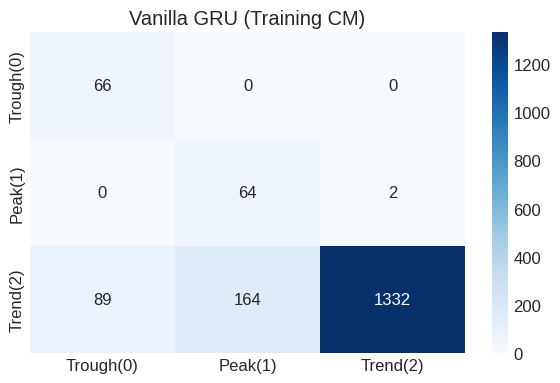

In [26]:
class VanillaRegimeGRU(nn.Module):
    def __init__(self, input_features=13, hidden_dim=32, output_classes=3):
        super(VanillaRegimeGRU, self).__init__()
        # Simple, standard architecture. No complex bottlenecks.
        self.bottleneck_dim = max(4, (input_features // 2) + 2)
        self.embedding = nn.Linear(input_features, self.bottleneck_dim)

        self.gru = nn.GRU(self.bottleneck_dim, hidden_dim, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_classes)

    def get_hidden_state(self, x):
        embedded_x = torch.relu(self.embedding(x))
        out, _ = self.gru(embedded_x)
        # Training strictly on the final hidden state of the sentence
        return out[:, -1, :]

    def forward(self, x):
        final_state = self.get_hidden_state(x)
        # Output directly to cross entropy (1-0-0 classification)
        logits = self.fc(final_state)
        return logits, final_state

def train_baseline(model, X_train, Y_train, epochs=150, lr=1e-3):
    print("\n--- TRAINING VANILLA GRU MODEL ---")
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=96, shuffle=True)

    # Pure Inverse Frequency Weights to handle class imbalance
    class_counts = np.bincount(Y_train)
    basic_weights = len(Y_train) / (len(class_counts) * class_counts)
    class_weights = torch.tensor(basic_weights, dtype=torch.float32).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    model.train()
    for epoch in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            logits, _ = model(bx.to(DEVICE))
            loss = criterion(logits, by.to(DEVICE))
            loss.backward()
            optimizer.step()
    model.eval()
    return model

def evaluate_baseline(model, X, Y, title="Baseline CM"):
    X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        logits, _ = model(X_tensor)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(Y, preds), annot=True, fmt='d', cmap='Blues',
                xticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'],
                yticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'])
    plt.title(title)
    plt.tight_layout()
    plt.show()

def get_probabilities(model, X):
    """Extract standard Softmax probabilities for Profiling & Grid Search"""
    X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits, _ = model(X_tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()
    return probs

# --- EXECUTION: BASELINE ---
baseline_model = VanillaRegimeGRU(input_features=13, hidden_dim=32).to(DEVICE)
train_baseline(baseline_model, X_train, Y_train, epochs=150)

evaluate_baseline(baseline_model, X_train, Y_train, title="Vanilla GRU (Training CM)")
mean_probs_val = get_probabilities(baseline_model, X_val)
mean_probs_test = get_probabilities(baseline_model, X_test)

## Phase III: Validation Profiling Lab

In [27]:
def profile_validation_extrema(clean_df, val_days, test_days, mean_probs):
    val_data = clean_df.iloc[-(val_days + test_days):-test_days].copy()
    min_n = min(len(val_data), len(mean_probs))
    val_data = val_data.iloc[-min_n:].copy()

    val_data['Prob_Trough'] = mean_probs[-min_n:, 0]
    val_data['Prob_Peak']   = mean_probs[-min_n:, 1]

    prices = val_data['Close'].values
    dates = val_data.index

    sma_10 = talib.SMA(prices, timeperiod=10)
    valid_idx = ~np.isnan(sma_10)
    min_swing = np.nanmean(sma_10) * 0.035
    coarse_peaks, _ = find_peaks(sma_10[valid_idx], distance=5, prominence=min_swing)
    coarse_troughs, _ = find_peaks(-sma_10[valid_idx], distance=5, prominence=min_swing)

    offset = np.argmax(valid_idx)
    coarse_peaks += offset
    coarse_troughs += offset

    records = []

    for ct in coarse_troughs:
        start = max(0, ct - 3)
        end = min(len(prices), ct + 4)
        local_min_idx = start + np.argmin(prices[start:end])

        r_min = val_data.iloc[local_min_idx]
        records.append({
            'Date': str(dates[local_min_idx].date()), 'Extremum': 'Trough(Buy)',
            'Price': round(float(r_min['Close']), 2),
            'Prob_Trough': round(float(r_min['Prob_Trough']), 3),
            'Prob_Peak': round(float(r_min['Prob_Peak']), 3)
        })

    for cp in coarse_peaks:
        start = max(0, cp - 3)
        end = min(len(prices), cp + 4)
        local_max_idx = start + np.argmax(prices[start:end])

        r_max = val_data.iloc[local_max_idx]
        records.append({
            'Date': str(dates[local_max_idx].date()), 'Extremum': 'Peak(Sell)',
            'Price': round(float(r_max['Close']), 2),
            'Prob_Trough': round(float(r_max['Prob_Trough']), 3),
            'Prob_Peak': round(float(r_max['Prob_Peak']), 3)
        })

    profile_df = pd.DataFrame(records).sort_values(by='Date').drop_duplicates(subset=['Date', 'Extremum']).reset_index(drop=True)
    print(f"\n--- VALIDATION EXTREMA PROFILING (Logged: {len(profile_df)}) ---")
    return profile_df

# --- EXECUTION: PROFILER ---
validation_profile_df = profile_validation_extrema(clean_df, VAL_DAYS_N, TEST_DAYS_N, mean_probs_val)
pd.set_option('display.max_rows', None)
display(validation_profile_df)


--- VALIDATION EXTREMA PROFILING (Logged: 4) ---


,Date,Extremum,Price,Prob_Trough,Prob_Peak
0,2018-01-31,Peak(Sell),32887.27,0.000,0.001
1,2018-02-14,Trough(Buy),30515.60,0.005,0.000
2,2018-03-20,Peak(Sell),31549.93,0.000,0.005
3,2018-10-30,Trough(Buy),24585.53,0.896,0.000


## Phase IV: Validation Grid Search & Out-of-Sample Execution


--- RUNNING VALIDATION GRID SEARCH (Vanilla Probabilities) ---
Optimal Vals -> Margin > 0.1 | Trades: 14

--- CHECKPOINT 3: Out-of-Sample Test Set Execution ---

Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2018-12-28   2018-12-28
End Period           2020-12-31   2020-12-31
Risk-Free Rate       0.0%         0.0%
Time in Market       100.0%       43.0%

Cumulative Return    6.88%        28.7%
CAGR﹪               3.44%        13.68%

Sharpe               0.27         0.92
Prob. Sharpe Ratio   64.67%       89.79%
Sortino              0.37         1.32
Sortino/√2           0.26         0.93
Omega                1.05         1.3

Max Drawdown         -28.06%      -18.95%
Max DD Date          2020-03-23   2020-03-23
Max DD Period Start  2019-04-10   2020-03-06
Max DD Perio

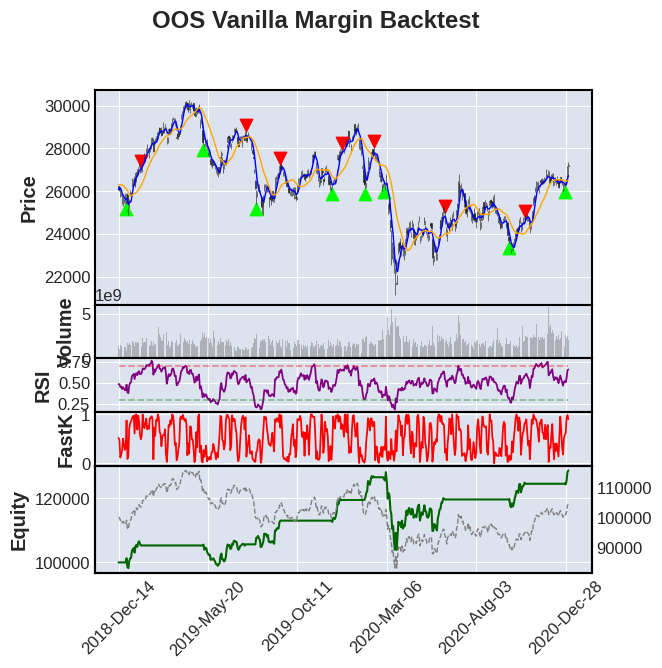

In [29]:
def validation_grid_search(clean_df, val_days, test_days, mean_probs):
    print("\n--- RUNNING VALIDATION GRID SEARCH (Vanilla Probabilities) ---")
    val_data = clean_df.iloc[-(val_days + test_days):-test_days].copy()
    min_n = min(len(val_data), len(mean_probs))
    val_data = val_data.iloc[-min_n:].copy()

    val_data['Prob_Trough'] = mean_probs[-min_n:, 0]
    val_data['Prob_Peak']   = mean_probs[-min_n:, 1]
    val_data['Prob_Trend']  = mean_probs[-min_n:, 2]

    # Compute Probability Margin (Top Class - Runner Up)
    sorted_probs = np.sort(mean_probs[-min_n:], axis=1)
    val_data['Prob_Margin'] = sorted_probs[:, -1] - sorted_probs[:, -2]

    grid_margins = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]

    best_score = -999.0
    best_margin = None

    for margin_thr in grid_margins:
        cash = 100000.0
        holdings = 0.0
        in_position = False
        strategy_values = []
        trades = 0

        for i in range(len(val_data)):
            price = val_data['Close'].iloc[i]
            open_price = val_data['Open'].iloc[i]

            if i == 0:
                strategy_values.append(cash)
                continue

            prev = val_data.iloc[i-1]

            is_trough = (prev['Prob_Trough'] > prev['Prob_Peak']) and (prev['Prob_Trough'] > prev['Prob_Trend'])
            is_peak = (prev['Prob_Peak'] > prev['Prob_Trough']) and (prev['Prob_Peak'] > prev['Prob_Trend'])

            # Without SGLD, we rely entirely on the classification margin
            go_long = is_trough and (prev['Prob_Margin'] > margin_thr)
            force_liquidate = is_peak and (prev['Prob_Margin'] > margin_thr)

            if go_long and not in_position:
                execution_price = open_price * 1.01
                holdings = cash / execution_price
                cash = 0.0
                in_position = True
                trades += 1
            elif force_liquidate and in_position:
                execution_price = open_price * 0.99
                cash = holdings * execution_price
                holdings = 0.0
                in_position = False
                trades += 1

            strategy_values.append(cash + (holdings * price))

        val_data['Strat_Val'] = strategy_values
        strat_ret = val_data['Strat_Val'].pct_change().dropna()

        if trades < 2 or strat_ret.std() == 0:
            sortino = -999.0
        else:
            try:
                sortino = qs.stats.sortino(strat_ret, rf=0.0)
                if np.isnan(sortino): sortino = -999.0
            except:
                sortino = -999.0

        if sortino > best_score:
            best_score = sortino
            best_margin = (margin_thr, trades)

    if best_margin:
        print(f"Optimal Vals -> Margin > {best_margin[0]} | Trades: {best_margin[1]}")
    else:
        print("Optimization failed to find a profitable configuration.")

    return best_margin[0] if best_margin else None

def run_extrema_backtest(clean_df, test_days, mean_probs, margin_thr):
    print(f"\n--- CHECKPOINT 3: Out-of-Sample Test Set Execution ---")
    data = clean_df.iloc[-test_days:].copy()
    min_n = min(len(data), len(mean_probs))
    data = data.iloc[-min_n:].copy()

    data['Prob_Trough'] = mean_probs[-min_n:, 0]
    data['Prob_Peak']   = mean_probs[-min_n:, 1]
    data['Prob_Trend']  = mean_probs[-min_n:, 2]

    sorted_probs = np.sort(mean_probs[-min_n:], axis=1)
    data['Prob_Margin'] = sorted_probs[:, -1] - sorted_probs[:, -2]

    cash = 100000.0
    holdings = 0.0
    in_position = False
    strategy_values = []
    buy_markers = [np.nan] * len(data)
    sell_markers = [np.nan] * len(data)

    start_price = data['Close'].iloc[0]
    data['Benchmark'] = data['Close'] * (100000.0 / start_price)

    for i in range(len(data)):
        price = data['Close'].iloc[i]
        open_price = data['Open'].iloc[i]

        if i == 0:
            strategy_values.append(cash)
            continue

        prev = data.iloc[i-1]

        is_trough = (prev['Prob_Trough'] > prev['Prob_Peak']) and (prev['Prob_Trough'] > prev['Prob_Trend'])
        is_peak = (prev['Prob_Peak'] > prev['Prob_Trough']) and (prev['Prob_Peak'] > prev['Prob_Trend'])

        go_long = is_trough and (prev['Prob_Margin'] > margin_thr)
        force_liquidate = is_peak and (prev['Prob_Margin'] > margin_thr)

        if go_long and not in_position:
            execution_price = open_price * 1.0005
            holdings = cash / execution_price
            cash = 0.0
            in_position = True
            buy_markers[i] = data['Low'].iloc[i] * 0.99

        elif force_liquidate and in_position:
            execution_price = open_price * 0.9995
            cash = holdings * execution_price
            holdings = 0.0
            in_position = False
            sell_markers[i] = data['High'].iloc[i] * 1.01

        strategy_values.append(cash + (holdings * price))

    data['Strategy'] = strategy_values
    strat_ret = data['Strategy'].pct_change().dropna()
    bench_ret = data['Benchmark'].pct_change().dropna()
    strat_ret.index = pd.to_datetime(strat_ret.index)
    bench_ret.index = pd.to_datetime(bench_ret.index)

    qs.reports.metrics(strat_ret, benchmark=bench_ret, prepare_returns=False)

    apds = [
        mpf.make_addplot(data['5D_MA'], color='blue', panel=0, width=1.0),
        mpf.make_addplot(data['20D_MA'], color='orange', panel=0, width=1.0),
        mpf.make_addplot(data['Volume'], type='bar', color='gray', panel=1, alpha=0.5, ylabel='Volume'),
        mpf.make_addplot(data['Micro_RSI'], color='purple', panel=2, ylabel='RSI'),
        mpf.make_addplot([0.70]*len(data), color='red', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot([0.30]*len(data), color='green', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot(data['Micro_FastK'], color='red', panel=3, ylabel='FastK'),
        mpf.make_addplot(data['Strategy'], panel=4, color='darkgreen', ylabel='Equity', width=1.5),
        mpf.make_addplot(data['Benchmark'], panel=4, color='gray', linestyle='--', width=1.0)
    ]
    if pd.Series(buy_markers).notna().any():
        apds.append(mpf.make_addplot(buy_markers, type='scatter', markersize=80, marker='^', color='lime', panel=0))
    if pd.Series(sell_markers).notna().any():
        apds.append(mpf.make_addplot(sell_markers, type='scatter', markersize=80, marker='v', color='red', panel=0))

    # FIX: 5 panel ratios matching the 5 panels above (Price, Volume, RSI, FastK, Equity)
    mpf.plot(data, type='candle', addplot=apds, panel_ratios=(4, 1, 1, 1, 2), figratio=(14, 14), figscale=1.2, title='OOS Vanilla Margin Backtest')

# --- EXECUTION: OPTIMIZE & TEST ---
optimal_margin = validation_grid_search(clean_df, VAL_DAYS_N, TEST_DAYS_N, mean_probs_val)
if optimal_margin is not None:
    run_extrema_backtest(clean_df, TEST_DAYS_N, mean_probs_test, optimal_margin)

## Phase V: Generalized 2D Heatmaps (Decision Boundaries)


--- GENERATING 2D DECISION BOUNDARY HEATMAPS ---


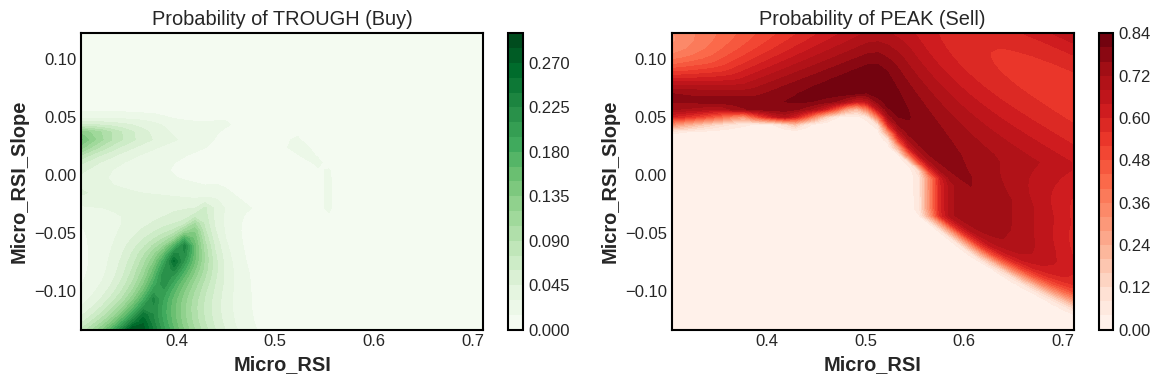

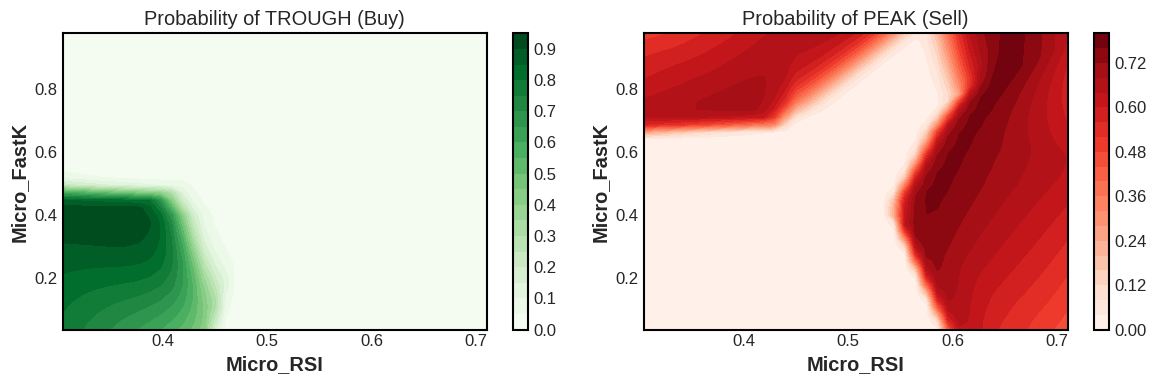

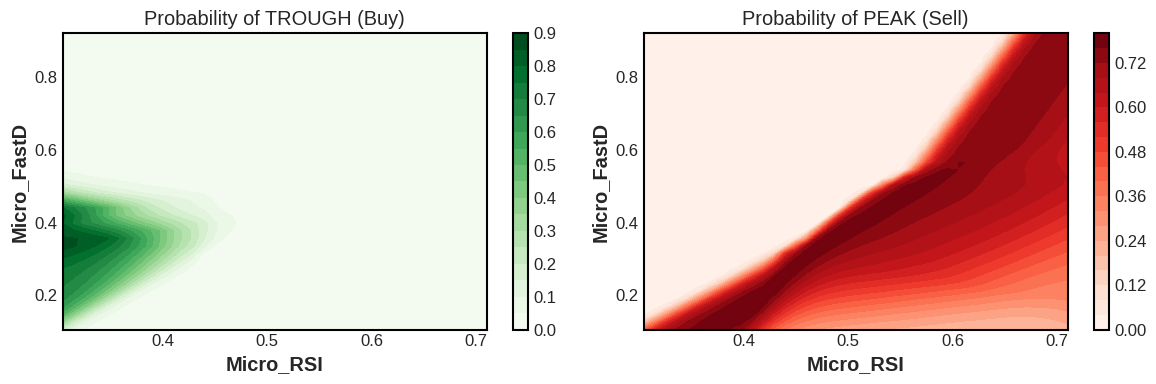

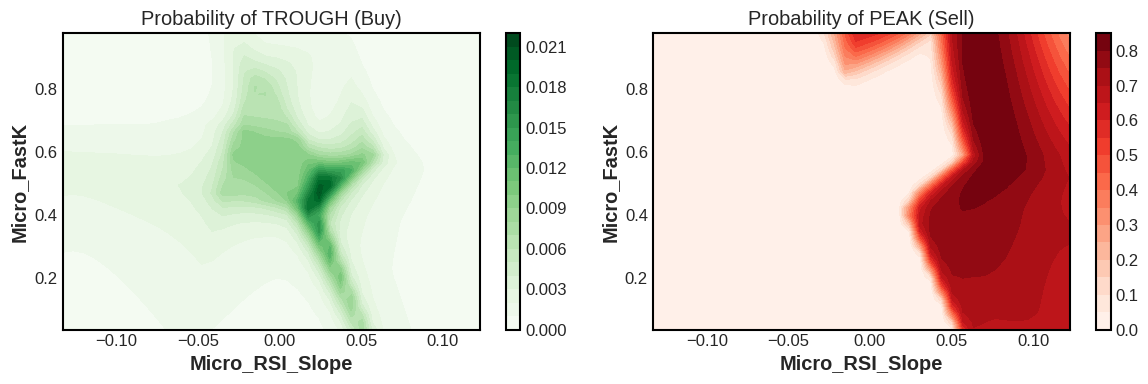

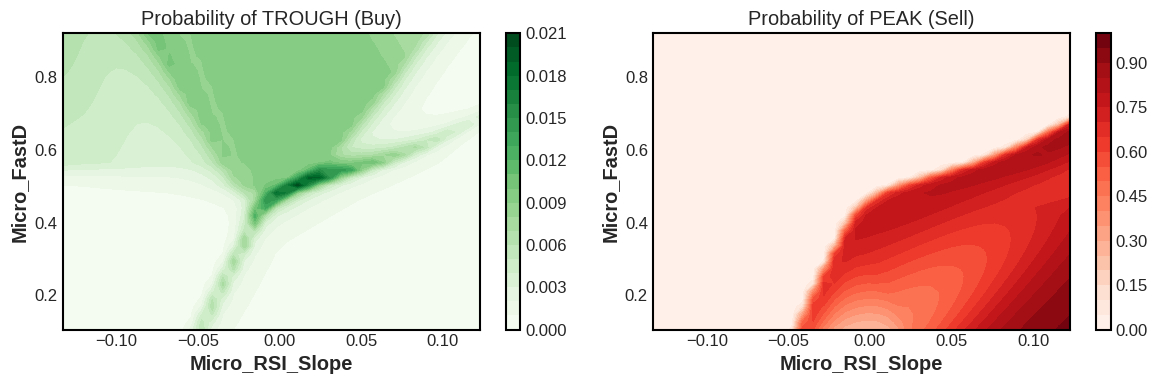

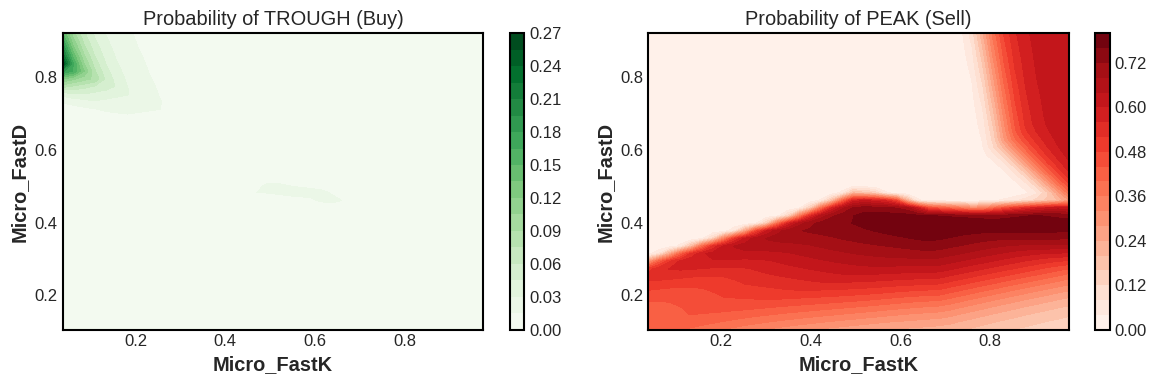

In [30]:
def plot_all_2d_pdp_heatmaps(model, scaler, feature_names, X_train):
    print("\n--- GENERATING 2D DECISION BOUNDARY HEATMAPS ---")
    feature_pairs = list(itertools.combinations(feature_names[:4], 2))

    X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
    X_train_orig = scaler.inverse_transform(X_train_reshaped)
    medians = np.median(X_train_orig, axis=0)

    model.eval()

    for f_x, f_y in feature_pairs:
        idx_x = feature_names.index(f_x)
        idx_y = feature_names.index(f_y)

        x_min, x_max = np.percentile(X_train_orig[:, idx_x], [5, 95])
        y_min, y_max = np.percentile(X_train_orig[:, idx_y], [5, 95])

        x_range = np.linspace(x_min, x_max, 40)
        y_range = np.linspace(y_min, y_max, 40)
        XX, YY = np.meshgrid(x_range, y_range)

        Z_trough = np.zeros(XX.shape)
        Z_peak = np.zeros(XX.shape)

        for i in range(XX.shape[0]):
            for j in range(XX.shape[1]):
                features = medians.copy()
                features[idx_x] = XX[i, j]
                features[idx_y] = YY[i, j]

                seq = np.tile(features, (10, 1))
                seq_scaled = scaler.transform(seq)
                t_input = torch.tensor(seq_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    logits, _ = model(t_input)
                    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
                    Z_trough[i, j] = probs[0]
                    Z_peak[i, j] = probs[1]

        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        c1 = ax[0].contourf(XX, YY, Z_trough, levels=20, cmap='Greens')
        ax[0].set_title('Probability of TROUGH (Buy)')
        ax[0].set_xlabel(f_x)
        ax[0].set_ylabel(f_y)
        fig.colorbar(c1, ax=ax[0])

        c2 = ax[1].contourf(XX, YY, Z_peak, levels=20, cmap='Reds')
        ax[1].set_title('Probability of PEAK (Sell)')
        ax[1].set_xlabel(f_x)
        ax[1].set_ylabel(f_y)
        fig.colorbar(c2, ax=ax[1])
        plt.tight_layout()
        plt.show()

# --- EXECUTION: HEATMAPS ---
plot_all_2d_pdp_heatmaps(baseline_model, pipeline.scaler, pipeline.feature_columns, X_train)